**Computing VaR and Expected Shortfall**

In this project we will be calculating:

* Historical VaR and CVaR
* Parametric VaR and CVaR
* Monte Carlo VaR and CVaR

Value-at-risk (VAR) - VAR is a statistical metric used to estimate the maximum potential loss on an investment portfolio over a specific time period, at a given confidence level.

Expected Shortfall (ES/Conditional VaR/CVaR) - ES is a financial risk measure that estimates the average loss of a portfolio in its worst-case scenarios.

**PART 1 - WITHOUT OOP**

In [34]:
# Importing required libraries

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import datetime as dt
import warnings
import scipy.stats as sp
from scipy.stats import shapiro

warnings.filterwarnings("ignore")

In [35]:
# Standardizing plot size for uniformity

plt.rcParams["figure.figsize"] = (15, 8)

In [36]:
# Downloading data

tickers = ['TCS.NS']
start1 = dt.date(2016,1,1)
end1 = dt.date(2025,12,31)

df1 = yf.download(tickers, start1, end1, auto_adjust=False)
print(f"Data for {tickers} has been downloaded")

[*********************100%***********************]  1 of 1 completed

Data for ['TCS.NS'] has been downloaded


In [37]:
df1 = df1.droplevel(level=1,axis=1)
df1.head()

Price,Adj Close,Close,High,Low,Open,Volume
Date,,,,,,
2016-01-01,935.559570,1208.199951,1219.500000,1206.125000,1219.500000,712262
2016-01-04,917.439819,1184.800049,1207.000000,1183.025024,1205.074951,1870184
2016-01-05,909.445129,1174.474976,1193.300049,1170.500000,1192.500000,2678020
2016-01-06,922.086182,1190.800049,1193.074951,1175.099976,1175.099976,2653228
2016-01-07,918.078674,1185.625000,1191.449951,1180.000000,1185.000000,3199580


In [38]:
df1['daily_returns'] = df1['Close'].pct_change()
df1.head()

Price,Adj Close,Close,High,Low,Open,Volume,daily_returns
Date,,,,,,,
2016-01-01,935.559570,1208.199951,1219.500000,1206.125000,1219.500000,712262,NaN
2016-01-04,917.439819,1184.800049,1207.000000,1183.025024,1205.074951,1870184,-0.019368
2016-01-05,909.445129,1174.474976,1193.300049,1170.500000,1192.500000,2678020,-0.008715
2016-01-06,922.086182,1190.800049,1193.074951,1175.099976,1175.099976,2653228,0.013900
2016-01-07,918.078674,1185.625000,1191.449951,1180.000000,1185.000000,3199580,-0.004346


In [39]:
df1.tail()

Price,Adj Close,Close,High,Low,Open,Volume,daily_returns
Date,,,,,,,
2025-12-23,3189.922363,3310.000000,3319.899902,3293.500000,3319.899902,2365420,-0.004481
2025-12-24,3198.596191,3319.000000,3327.100098,3296.100098,3304.100098,1367708,0.002719
2025-12-26,3161.010742,3280.000000,3320.000000,3271.800049,3313.100098,1176664,-0.011751
2025-12-29,3133.544678,3251.500000,3288.000000,3242.899902,3280.000000,2079473,-0.008689
2025-12-30,3129.015137,3246.800049,3267.500000,3239.500000,3250.000000,2807593,-0.001445


In [40]:
df1 = df1.dropna()
df1.head()

Price,Adj Close,Close,High,Low,Open,Volume,daily_returns
Date,,,,,,,
2016-01-04,917.439819,1184.800049,1207.000000,1183.025024,1205.074951,1870184,-0.019368
2016-01-05,909.445129,1174.474976,1193.300049,1170.500000,1192.500000,2678020,-0.008715
2016-01-06,922.086182,1190.800049,1193.074951,1175.099976,1175.099976,2653228,0.013900
2016-01-07,918.078674,1185.625000,1191.449951,1180.000000,1185.000000,3199580,-0.004346
2016-01-08,928.280579,1198.800049,1203.675049,1186.250000,1192.500000,1907544,0.011112


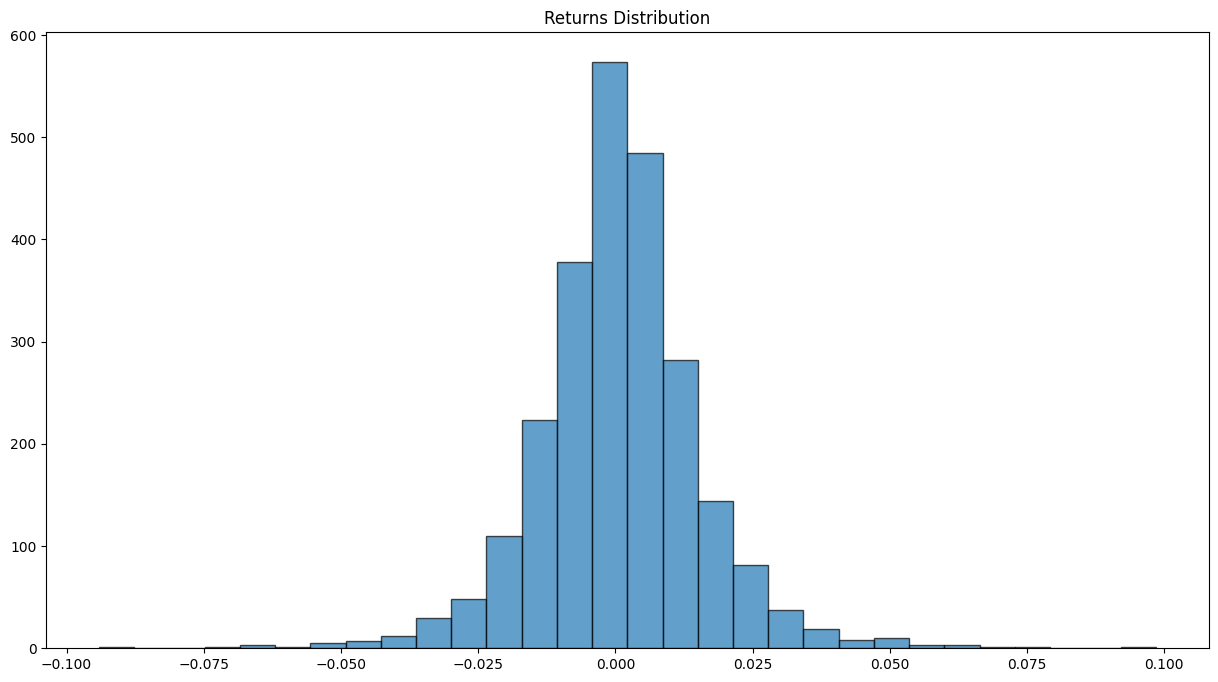

In [41]:
# Visualizing the returns distribution

plt.hist(
    df1['daily_returns'],
    bins=30,               # Divide data into 30 intervals
    density=False,
    edgecolor='black',     # Add borders to distinguish bins clearly
    alpha=0.7              # Add slight transparency
)

plt.title('Returns Distribution')
plt.show()

In [42]:
# Calculating statistics

average_daily_returns = np.mean(df1['daily_returns'])
average_annualized_returns = ((1 + average_daily_returns) ** 252) - 1
daily_std_dev = np.std(df1['daily_returns'])
annual_std_dev = daily_std_dev * np.sqrt(252)
skewness1 = sp.skew(df1['daily_returns'])
kurtosis1 = sp.kurtosis(df1['daily_returns'])

print(f"Average daily returns are {average_daily_returns} and average annualized returns are {average_annualized_returns}")
print(f"Daily standard deviation is {daily_std_dev} and annualized standard deviation is {annual_std_dev}")
print(f"Skewness of the distribution is {skewness1} and kurtosis is {kurtosis1}")

Average daily returns are 0.000510181987301073 and average annualized returns are 0.1371590332925019
Daily standard deviation is 0.014809487887204306 and annualized standard deviation is 0.23509333196259583
Skewness of the distribution is 0.11123967683029581 and kurtosis is 3.777890332815481


In [43]:
# Running Shapiro test to check normality of distribution

p_value = shapiro(df1['daily_returns'])[1]


# Print the results
if p_value <= 0.05:
    print("Null hypothesis of normality is rejected.")
else:
    print("Null hypothesis of normality is accepted.")


Null hypothesis of normality is rejected.


Historical VaR is -2.2214670363550657


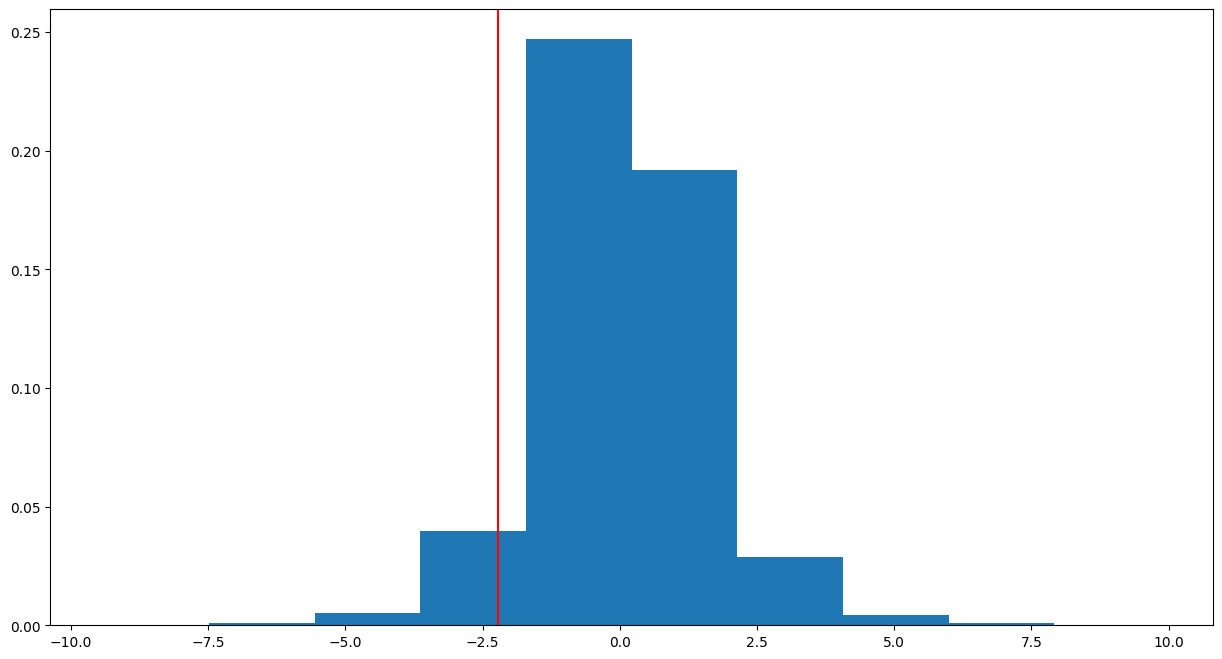

In [44]:
# Calculating Historical VAR

var_level = 95

return_percent = df1['daily_returns'] * 100

var_95 = np.percentile(return_percent,100-var_level)
print(f"Historical VaR is {var_95}")

sorted_returns = sorted(return_percent)
plt.hist(sorted_returns, density=True, stacked=True)
plt.axvline(x=var_95, color='r', linestyle='-',
            label="VaR 95: {0:.2f}%".format(var_95))
plt.show()

The historical CVaR(95) is -3.293799438460837


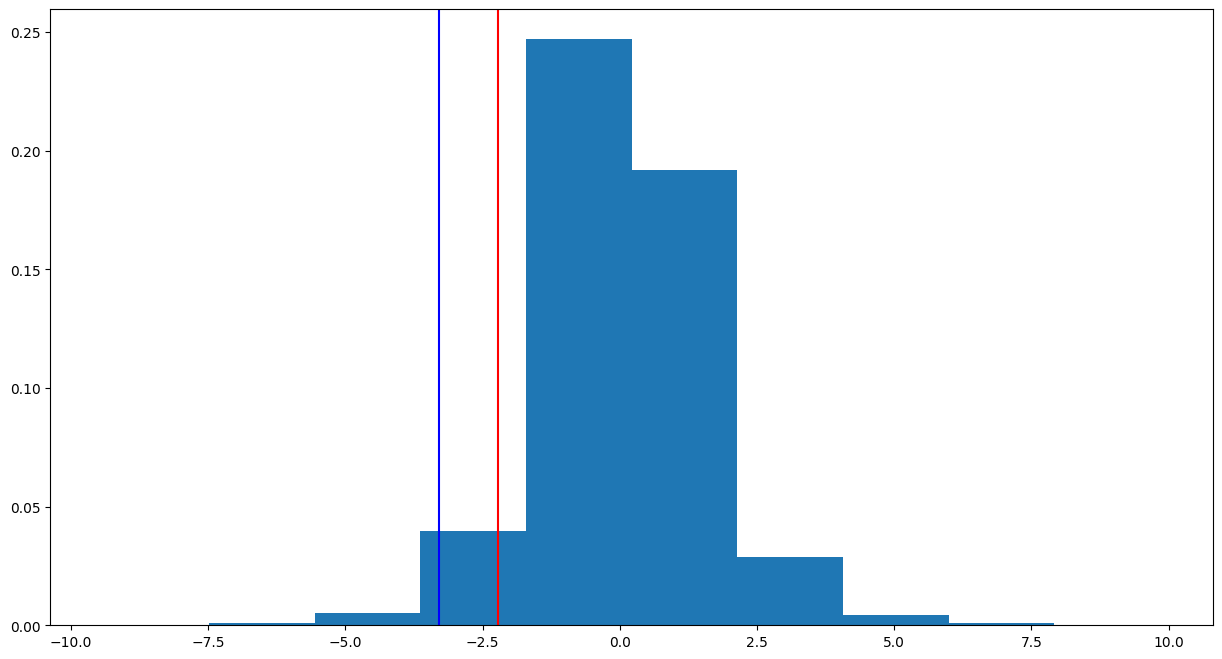

In [45]:
# Calculating Historical ES
es_95 = return_percent[return_percent < var_95].mean()
print(f"The historical CVaR(95) is {es_95}")

sorted_returns = sorted(return_percent)
plt.hist(sorted_returns, density=True, stacked=True)
plt.axvline(x=var_95, color='r', linestyle='-',
            label="VaR 95: {0:.2f}%".format(var_95))
plt.axvline(x=es_95, color='b', linestyle='-',
            label="VaR 95: {0:.2f}%".format(es_95))
plt.show()

In [46]:
# Calculating Parametric VaR and ES

from scipy.stats import norm

# Set the parameters
#mu = av_daily_rets
#vol = std_daily
mu = np.mean(return_percent)
vol = np.std(return_percent)

significance_level = (100 - var_level)/100
print(f"Significance level is {significance_level}.")

par_var_95 = norm.ppf(significance_level, mu, vol)
print(f"The parametric VaR(95) is {par_var_95}.")

# Calculate the parametric CVaR(95)
par_es_95 = return_percent[return_percent < par_var_95].mean()
print(f"The historical CVaR(95) is {par_es_95}.")

Significance level is 0.05.
The parametric VaR(95) is -2.384925787726086.
The historical CVaR(95) is -3.4532412946930675.


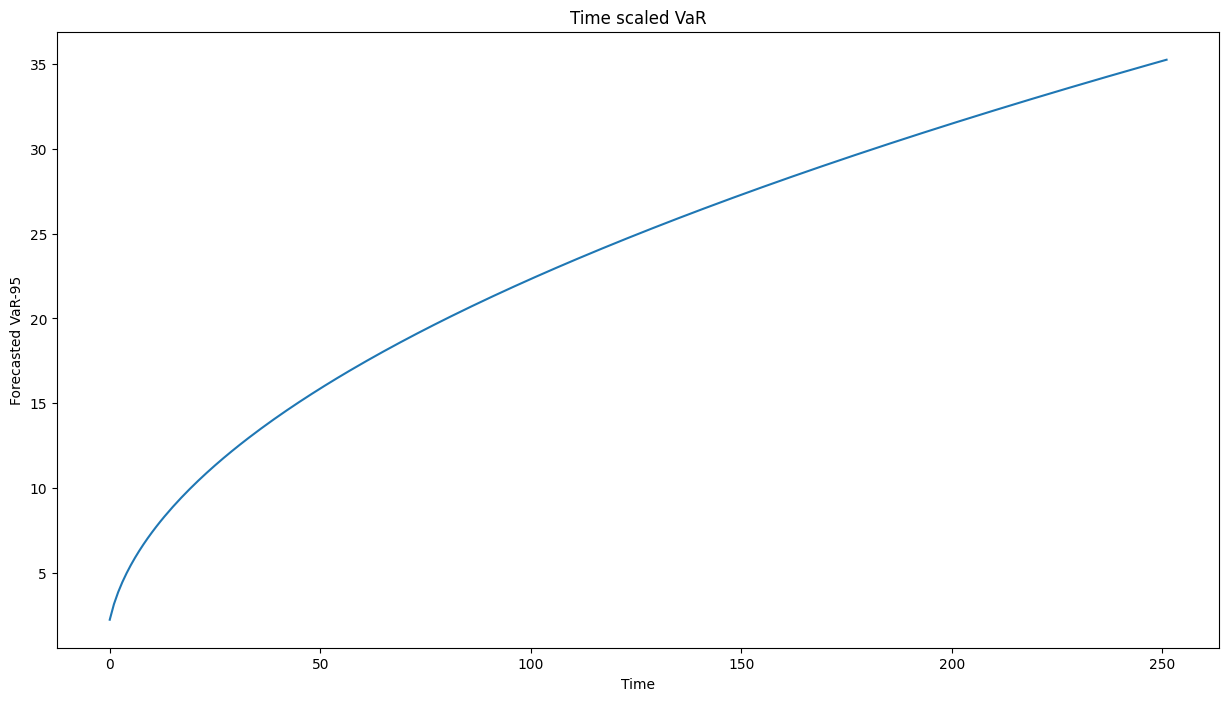

In [47]:
# Scaling the VaR

def plot_var(array):
    d = pd.DataFrame(abs(array))
    d[1].plot(xlabel='Time', ylabel='Forecasted VaR-95',
              title="Time scaled VaR")
    plt.show()

VaR_arr = np.empty([252, 2])

# Loop through the time period
for i in range(252):
    VaR_arr[i, 0] = i
    VaR_arr[i, 1] = var_95*np.sqrt(i+1)

# Plot the results
plot_var(VaR_arr)

In [48]:
# Using Monte Carlo Simulations to calculate VaR and ES

np.random.seed(100)

mu = average_daily_returns
vol = daily_std_dev
n_sims = 1000
T = 252
sim_returns = []

for i in range(n_sims):

    # Generate the Random Walk using the mu, vol computed above
    rand_returns = np.random.normal(mu, vol, T)

    # Save the results
    sim_returns.append(rand_returns)

# Calculate and print the VaR(95)
mc_var_95 = np.percentile(sim_returns, 5)
print("VaR(95) computed from the Monte Carlo Simulations: ",
      round(100*mc_var_95, 2), "%")


VaR(95) computed from the Monte Carlo Simulations:  -2.38 %


In [49]:
def flatten(listoflists):
    return [item for sublist in sim_returns for item in sublist]

sims = pd.Series(flatten(sim_returns))
len(sims)

sims[sims < mc_var_95]

mc_es_95 = sims[sims < mc_var_95].mean()
print("CVaR(95) computed from the Monte Carlo Simulations: ",
      round(100*mc_es_95, 2), "%")

CVaR(95) computed from the Monte Carlo Simulations:  -2.99 %


**PART 2 - USING OOP**

In [50]:
# Defining a class 'computeVarESC' which can be re-used

class computeVarESC:

  def __init__(self, ticker, start, end, var_level=95):
    self.ticker = ticker
    self.start = start
    self.end = end
    self.var_level = var_level
    self.significance = (100 - var_level) / 100
    self.data = None
    self.returns = None

  def fetch_data(self):
    df = yf.download(self.ticker, self.start, self.end, auto_adjust=False)
    if isinstance(df.columns, pd.MultiIndex):
      df = df.droplevel(1,1)
    df["daily_returns"] = df['Close'].pct_change()
    self.data = df.dropna()
    self.returns = self.data["daily_returns"] * 100
    print(f"Data for {self.ticker} downloaded: {len(self.data)} rows")
    return self

  def describe(self):
    r = self.returns / 100
    stats = {
        "avg_daily_return": r.mean(),
        "avg_annual_return": (1 + r.mean()) ** 252 - 1,
        "daily_std": r.std(),
        "annual_std": r.std()* np.sqrt(252),
        "skew": sp.skew(r),
        "kurtosis": sp.kurtosis(r),
    }
    for k, v in stats.items():
      print(f"{k}: {v:.6f}")
    return stats

  def test_normality(self):
    p_value = shapiro(self.returns)[1]
    verdict = "rejected" if p_value <= 0.05 else "accepted"
    print(f"p-value: {p_value:.4f}; normality: {verdict}")
    return p_value

  # Calculating Historical, Parametric and Monte Carlo VaR and ES

  def historical_var_es(self):
    var = np.percentile(self.returns, 100-self.var_level)
    es = self.returns[self.returns < var].mean()
    self.hist_var, self.hist_es = var, es
    print(f"Historical VaR({self.var_level}): {var:.2f}%; Historical ES: {es:.2f}%")
    return var, es

  def parametric_var_es(self):
    mu, vol = self.returns.mean(), self.returns.std()
    var = norm.ppf(self.significance, mu, vol)
    es = self.returns[self.returns < var].mean()
    self.param_var, self.param_es = var, es
    print(f"Parametric VaR({self.var_level}): {var * 100:.2f}%; ES: {es * 100:.2f}%")
    return var, es

  def monte_carlo_var_es(self, n_sims=1000, horizon=252, seed=100):
    np.random.seed(seed)
    mu, vol = self.returns.mean() / 100, self.returns.std() / 100
    sims = np.random.normal(mu, vol, (n_sims, horizon))
    var = np.percentile(sims, 100 - self.var_level)
    es = sims[sims < var].mean()
    self.mc_var, self.mc_es = var, es
    print(f"Monte Carlo VaR({self.var_level}): {self.mc_var:.2f}%; ES: {self.mc_es:.2f}%")
    return var, es

  def scale_var(self, days=252):
    if not hasattr(self, "hist_var"):
      self.historical_var_es()
    scaled = self.hist_var * np.sqrt(np.arange(1, days + 1))
    pd.Series(np.abs(scaled)).plot(
        xlabel="Time", ylabel=f"Forecasted VaR-{self.var_level}",
        title="Time Scaled VaR"
    )
    plt.show()
    return scaled

  # ----- plots -----

  def plot_returns(self):
    plt.hist(self.returns / 100, bins=30, edgecolor="black", alpha=0.7)
    plt.title("Returns Distribution")
    plt.show()

  # ----- running all functions -----

  def run_all(self):
    # Runs full pipeline end to end and returns a summary dict.
    self.fetch_data()
    self.plot_returns()
    self.describe()
    self.test_normality()
    self.historical_var_es()
    self.parametric_var_es()
    self.monte_carlo_var_es()
    self.scale_var()
    return {
        "historical": (self.hist_var, self.hist_es),
        "parametric": (self.param_var, self.param_es),
        "monte_carlo": (self.mc_var, self.mc_es),
    }

[*********************100%***********************]  1 of 1 completed

Data for colpal.ns downloaded: 2468 rows


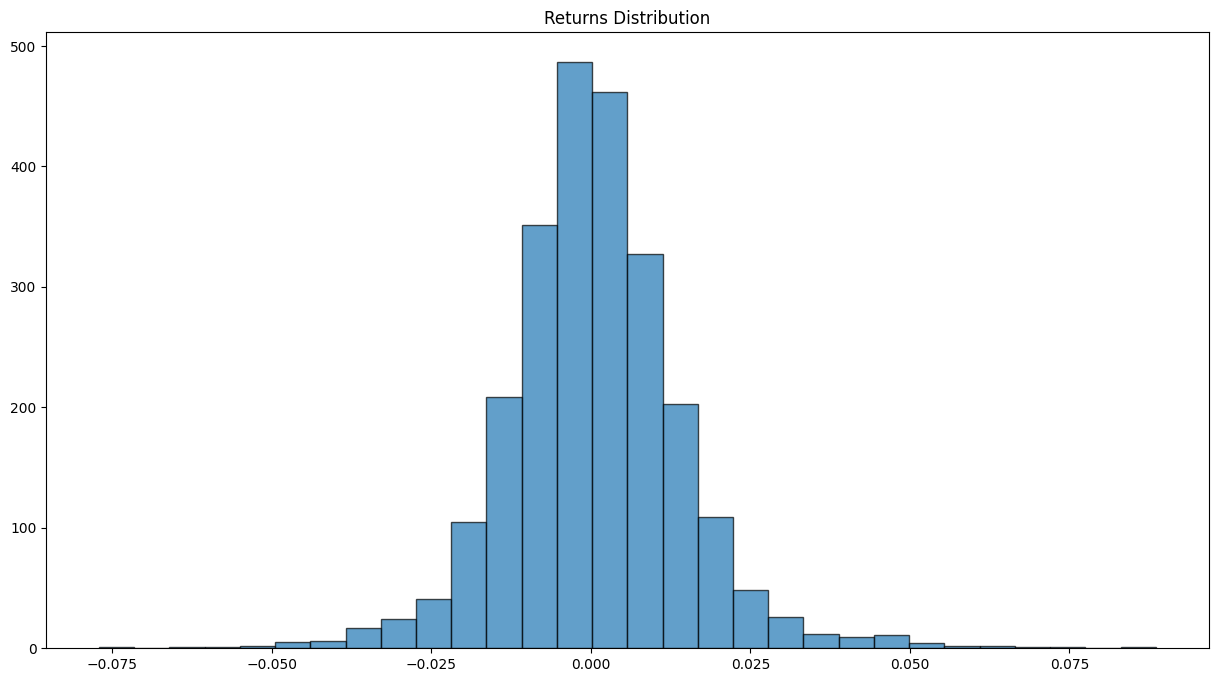

avg_daily_return: 0.000396
avg_annual_return: 0.104859
daily_std: 0.013783
annual_std: 0.218804
skew: 0.332352
kurtosis: 3.405159
p-value: 0.0000; normality: rejected
Historical VaR(95): -2.02%; Historical ES: -2.94%
Parametric VaR(95): -222.76%; ES: -322.93%
Monte Carlo VaR(95): -0.02%; ES: -0.03%


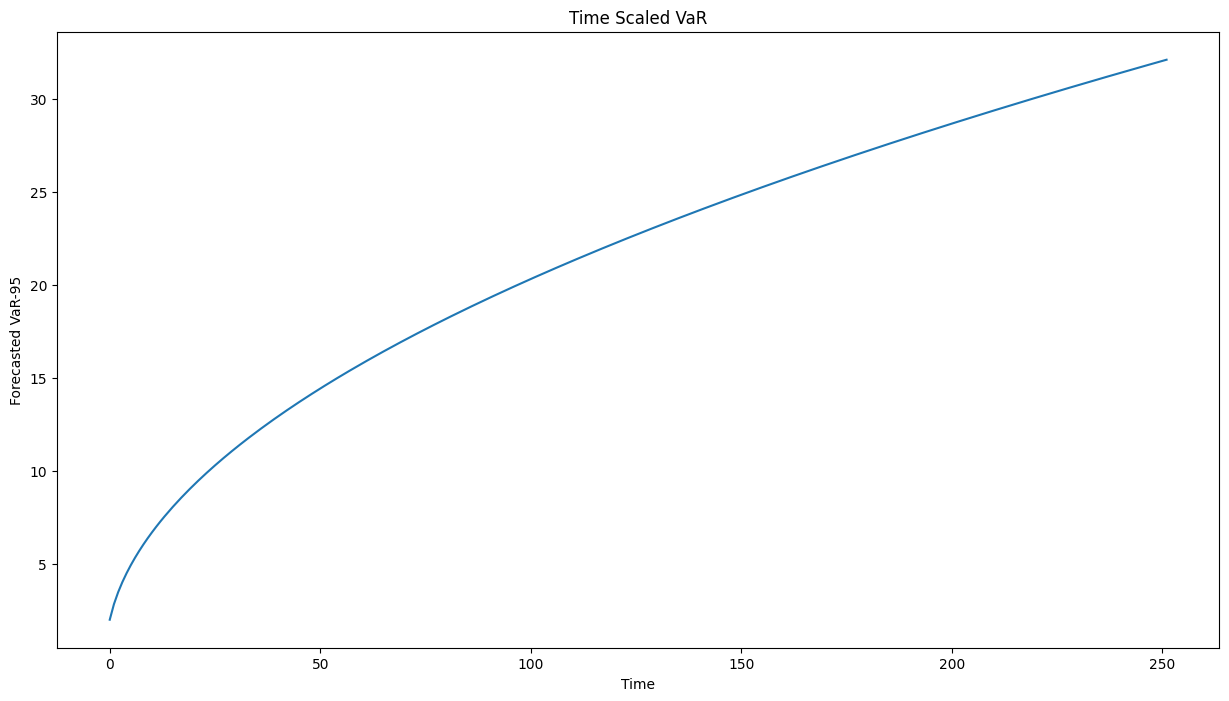

{'historical': (np.float64(-2.020989107395262),
  np.float64(-2.941199500018189)),
 'parametric': (np.float64(-2.2275858865848748),
  np.float64(-3.229252265869911)),
 'monte_carlo': (np.float64(-0.022223547417014128),
  np.float64(-0.027924961040899247))}

In [51]:
# Using the defined class

analyzer = computeVarESC("colpal.ns", dt.date(2016,1,1), dt.date(2025,12,31), var_level=95)
results = analyzer.run_all()
results